# Module 1 — RFM Analysis & Customer Segmentation
## Goal: Score every customer on Recency, Frequency, Monetary value
## Output: RFM scores + customer segments saved to outputs/

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv('../data/telco_churn_cleaned.csv')
print(f"Loaded clean dataset: {df.shape}")
df.head()

Loaded clean dataset: (7032, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# Recency = how long customer has been with us (tenure)
# Higher tenure = more recent/loyal = higher score

df['R_Score'] = pd.qcut(df['tenure'], q=4, labels=[1,2,3,4])
df['R_Score'] = df['R_Score'].astype(int)

print("Recency Score Distribution:")
print(df['R_Score'].value_counts().sort_index())

Recency Score Distribution:
R_Score
1    1843
2    1715
3    1719
4    1755
Name: count, dtype: int64


In [3]:
# Frequency = number of services the customer uses
# Services: PhoneService, MultipleLines, InternetService,
# OnlineSecurity, OnlineBackup, DeviceProtection,
# TechSupport, StreamingTV, StreamingMovies

service_cols = ['PhoneService', 'MultipleLines', 'OnlineSecurity',
                'OnlineBackup', 'DeviceProtection', 'TechSupport',
                'StreamingTV', 'StreamingMovies']

# Count how many services each customer uses (Yes = 1)
df['ServiceCount'] = df[service_cols].apply(
    lambda row: sum(1 for val in row if val == 'Yes'), axis=1
)

df['F_Score'] = pd.qcut(df['ServiceCount'].rank(method='first'), 
                         q=4, labels=[1,2,3,4])
df['F_Score'] = df['F_Score'].astype(int)

print("Service Count Distribution:")
print(df['ServiceCount'].value_counts().sort_index())
print("\nFrequency Score Distribution:")
print(df['F_Score'].value_counts().sort_index())

Service Count Distribution:
ServiceCount
0      80
1    1697
2    1186
3     965
4     921
5     906
6     674
7     395
8     208
Name: count, dtype: int64

Frequency Score Distribution:
F_Score
1    1758
2    1758
3    1758
4    1758
Name: count, dtype: int64


In [4]:
# Monetary = MonthlyCharges (how much customer pays per month)

df['M_Score'] = pd.qcut(df['MonthlyCharges'], q=4, labels=[1,2,3,4])
df['M_Score'] = df['M_Score'].astype(int)

print("Monetary Score Distribution:")
print(df['M_Score'].value_counts().sort_index())

Monetary Score Distribution:
M_Score
1    1758
2    1761
3    1755
4    1758
Name: count, dtype: int64


RFM Score Distribution:
count    7032.000000
mean        7.481086
std         2.727815
min         3.000000
25%         5.000000
50%         7.000000
75%        10.000000
max        12.000000
Name: RFM_Score, dtype: float64


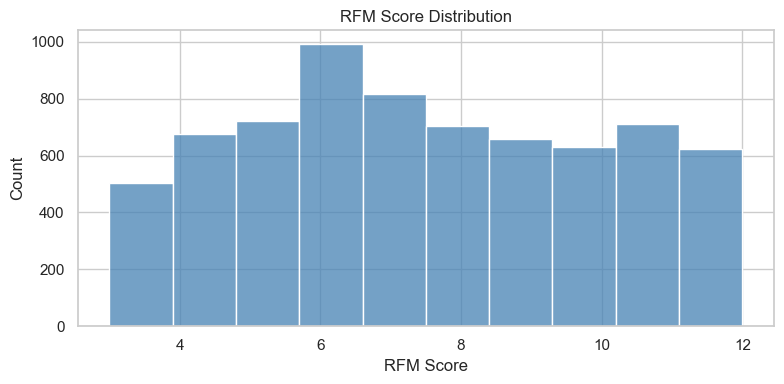

In [5]:
# Total RFM Score = R + F + M (range: 3 to 12)
df['RFM_Score'] = df['R_Score'] + df['F_Score'] + df['M_Score']

print("RFM Score Distribution:")
print(df['RFM_Score'].describe())

plt.figure(figsize=(8,4))
sns.histplot(df['RFM_Score'], bins=10, color='steelblue', edgecolor='white')
plt.title('RFM Score Distribution')
plt.xlabel('RFM Score')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Assign Customer Segments

In [6]:
def assign_segment(score):
    if score >= 10:
        return 'Champions'
    elif score >= 8:
        return 'Loyal Customers'
    elif score >= 6:
        return 'At Risk'
    else:
        return 'Inactive'

df['Segment'] = df['RFM_Score'].apply(assign_segment)

print("Segment Distribution:")
print(df['Segment'].value_counts())
print("\nSegment %:")
print((df['Segment'].value_counts(normalize=True) * 100).round(2))

Segment Distribution:
Segment
Champions          1962
Inactive           1901
At Risk            1808
Loyal Customers    1361
Name: count, dtype: int64

Segment %:
Segment
Champions          27.90
Inactive           27.03
At Risk            25.71
Loyal Customers    19.35
Name: proportion, dtype: float64


 Visualize Segments

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_4416\1759270695.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_counts.index, y=segment_counts.values, palette=colors)


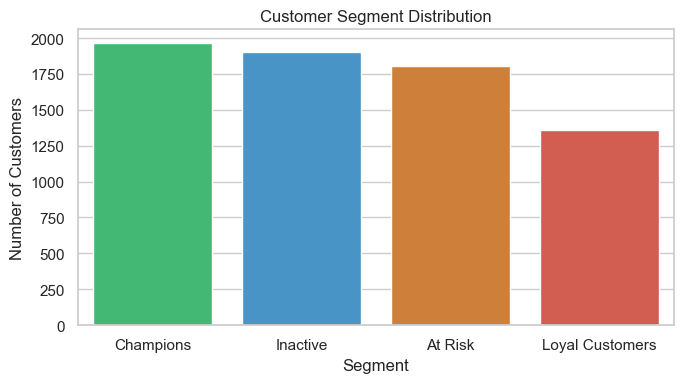

In [7]:
segment_counts = df['Segment'].value_counts()

plt.figure(figsize=(7,4))
colors = ['#2ecc71','#3498db','#e67e22','#e74c3c']
sns.barplot(x=segment_counts.index, y=segment_counts.values, palette=colors)
plt.title('Customer Segment Distribution')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

Revenue by Segment

Revenue by Segment:
                 Total Monthly Revenue  Avg Monthly Charges  Customer Count
Segment                                                                    
Champions                    187350.05                95.49            1962
Loyal Customers              104480.75                76.77            1361
At Risk                      102169.00                56.51            1808
Inactive                      61661.20                32.44            1901


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_4416\2723094992.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_revenue.index, y=segment_revenue['Total Monthly Revenue'], palette=colors)


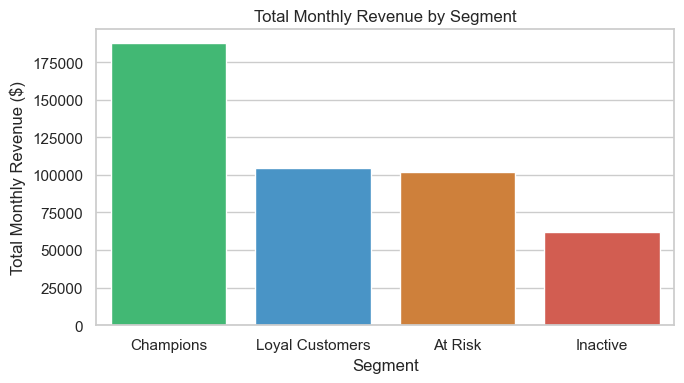

In [8]:
segment_revenue = df.groupby('Segment')['MonthlyCharges'].agg(['sum','mean','count'])
segment_revenue.columns = ['Total Monthly Revenue', 'Avg Monthly Charges', 'Customer Count']
segment_revenue = segment_revenue.sort_values('Total Monthly Revenue', ascending=False)

print("Revenue by Segment:")
print(segment_revenue.round(2))

plt.figure(figsize=(7,4))
sns.barplot(x=segment_revenue.index, y=segment_revenue['Total Monthly Revenue'], palette=colors)
plt.title('Total Monthly Revenue by Segment')
plt.xlabel('Segment')
plt.ylabel('Total Monthly Revenue ($)')
plt.tight_layout()
plt.show()

Churn Rate by Segment

Churn Rate by Segment (%):
Segment
Loyal Customers    32.04
At Risk            31.36
Inactive           25.93
Champions          19.01
Name: Churn, dtype: float64


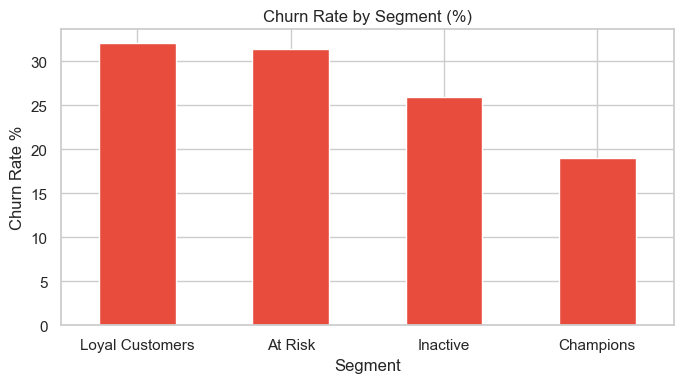

In [10]:
churn_by_segment = df.groupby('Segment')['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).round(2)

print("Churn Rate by Segment (%):")
print(churn_by_segment.sort_values(ascending=False))

plt.figure(figsize=(7,4))
churn_by_segment.sort_values(ascending=False).plot(
    kind='bar', color='#e74c3c', edgecolor='white'
)
plt.title('Churn Rate by Segment (%)')
plt.xlabel('Segment')
plt.ylabel('Churn Rate %')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [9]:
# Save full RFM dataset
rfm_output = df[['customerID','tenure','MonthlyCharges','TotalCharges',
                  'R_Score','F_Score','M_Score','RFM_Score','Segment','Churn']]

rfm_output.to_csv('../outputs/rfm_segments.csv', index=False)
print("RFM segments saved to ../outputs/rfm_segments.csv")
print(f"Shape: {rfm_output.shape}")
rfm_output.head(10)

RFM segments saved to ../outputs/rfm_segments.csv
Shape: (7032, 10)


,customerID,tenure,MonthlyCharges,TotalCharges,R_Score,F_Score,M_Score,RFM_Score,Segment,Churn
0,7590-VHVEG,1,29.85,29.85,1,1,1,3,Inactive,No
1,5575-GNVDE,34,56.95,1889.50,3,2,2,7,At Risk,No
2,3668-QPYBK,2,53.85,108.15,1,2,2,5,Inactive,Yes
3,7795-CFOCW,45,42.30,1840.75,3,2,2,7,At Risk,No
4,9237-HQITU,2,70.70,151.65,1,1,3,5,Inactive,Yes
5,9305-CDSKC,8,99.65,820.50,1,3,4,8,Loyal Customers,Yes
6,1452-KIOVK,22,89.10,1949.40,2,3,3,8,Loyal Customers,No
7,6713-OKOMC,10,29.75,301.90,2,1,1,4,Inactive,No
8,7892-POOKP,28,104.80,3046.05,2,4,4,10,Champions,Yes
9,6388-TABGU,62,56.15,3487.95,4,2,2,8,Loyal Customers,No


## RFM Analysis Summary

| Segment | Description | Business Action |
|---|---|---|
| Champions | High tenure, many services, high spend | Reward & upsell |
| Loyal Customers | Good scores across RFM | Nurture & retain |
| At Risk | Declining engagement | Proactive outreach |
| Inactive | Low tenure, few services, low spend | Re-engagement campaign |

**Key Finding:** At Risk and Inactive segments show highest churn rates — these are the priority targets for Module 3 retention strategies.